In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import helper

In [2]:
df = helper.prepare_data()

In [15]:
class DecisionNode:
  def __init__(self, impurity=None, feature_index=None, threshold=None, left=None, right=None):
    self.left = left
    self.right = right
    self.impurity = impurity
    self.feature_index = feature_index
    self.threshold = threshold

class LeafNode:
    def __init__(self, y):
        self.class_counts = {}
        unique, counts = np.unique(y, return_counts=True)
        for label, count in zip(unique, counts):
            self.class_counts[label] = count
        self.prediction_value = unique[np.argmax(counts)]

class DecisionTreeClassifierFromScratch:
  def __init__(self, min_sample_split=3, min_impurity=1e-7, max_depth=10, criterion='gini'):
    self.root = None
    self.min_sample_split = min_sample_split
    self.min_impurity = min_impurity
    self.max_depth = max_depth
    if criterion == 'entropy':
      self.criterion = 'entropy'
      self.criterion_name = 'entropy'
    else:
      self.criterion = 'gini'
      self.criterion_name = 'gini'
    self.n_classes_ = None
    self.classes_ = None

  def _impurity_from_counts(self, class_counts, n):
    """Compute gini or entropy from class count array — fully vectorized."""
    if n == 0:
      return 0.0
    p = class_counts / n
    if self.criterion == 'gini':
      return 1.0 - np.sum(p * p)
    else:
      mask = p > 0
      return -np.sum(p[mask] * np.log2(p[mask]))

  def _find_best_split_sorted(self, X, y):
    """
    Optimized split finder: for each feature, sort once O(n log n),
    then scan linearly with cumulative class counts O(n).
    Skips duplicate thresholds. No array copies during search.
    """
    n_samples, n_features = X.shape

    # Precompute total class counts
    total_counts = np.zeros(self.n_classes_, dtype=np.float64)
    for c in range(self.n_classes_):
      total_counts[c] = np.sum(y == self.classes_[c])
    parent_impurity = self._impurity_from_counts(total_counts, n_samples)

    best_gain = 0.0
    best_feature = -1
    best_threshold = 0.0

    for feature_index in range(n_features):
      sorted_indices = np.argsort(X[:, feature_index])
      sorted_vals = X[sorted_indices, feature_index]
      sorted_y = y[sorted_indices]

      left_counts = np.zeros(self.n_classes_, dtype=np.float64)
      right_counts = total_counts.copy()

      for i in range(1, n_samples):
        c_idx = self.class_to_idx_[sorted_y[i - 1]]
        left_counts[c_idx] += 1.0
        right_counts[c_idx] -= 1.0

        # Skip duplicate feature values — no new split boundary
        if sorted_vals[i] == sorted_vals[i - 1]:
          continue

        n_left = float(i)
        n_right = float(n_samples - i)
        left_imp = self._impurity_from_counts(left_counts, n_left)
        right_imp = self._impurity_from_counts(right_counts, n_right)
        gain = parent_impurity - (n_left / n_samples) * left_imp - (n_right / n_samples) * right_imp

        if gain > best_gain:
          best_gain = gain
          best_feature = feature_index
          best_threshold = (sorted_vals[i - 1] + sorted_vals[i]) / 2.0

    return best_gain, best_feature, best_threshold

  def _build_tree(self, X, y, current_depth=0):
    n_samples = X.shape[0]
    if (n_samples >= self.min_sample_split) and (current_depth < self.max_depth):
      impurity, best_feature, best_threshold = self._find_best_split_sorted(X, y)
      if impurity > self.min_impurity and best_feature >= 0:
        left_mask = X[:, best_feature] >= best_threshold
        right_mask = ~left_mask
        if np.any(left_mask) and np.any(right_mask):
          true_branch = self._build_tree(X[left_mask], y[left_mask], current_depth + 1)
          false_branch = self._build_tree(X[right_mask], y[right_mask], current_depth + 1)
          return DecisionNode(impurity=impurity, feature_index=best_feature, threshold=best_threshold,
                              left=true_branch, right=false_branch)
    return LeafNode(y)

  def fit(self, X, y):
    y_flat = np.asarray(y).ravel()
    self.classes_ = np.unique(y_flat)
    self.n_classes_ = len(self.classes_)
    self.class_to_idx_ = {c: i for i, c in enumerate(self.classes_)}
    self.root = self._build_tree(np.asarray(X, dtype=np.float64), y_flat, current_depth=0)

  def predict_sample(self, x, tree=None):
    if isinstance(tree, LeafNode):
      return tree.prediction_value
    if tree is None:
      tree = self.root
    feature_value = x[tree.feature_index]
    branch = tree.right
    if isinstance(feature_value, (int, float, np.integer, np.floating)):
      if feature_value >= tree.threshold:
        branch = tree.left
    elif feature_value == tree.threshold:
      branch = tree.left
    return self.predict_sample(x, branch)

  def predict(self, test_X):
    x = np.array(test_X)
    y_pred = np.array([self.predict_sample(sample) for sample in x])
    return y_pred

  def predict_proba_sample(self, x, tree=None):
    if tree is None:
        tree = self.root
    if isinstance(tree, LeafNode):
        total = sum(tree.class_counts.values())
        prob_1 = tree.class_counts.get(1, 0) / total
        return prob_1
    feature_value = x[tree.feature_index]
    if feature_value >= tree.threshold:
        return self.predict_proba_sample(x, tree.left)
    else:
        return self.predict_proba_sample(x, tree.right)

  def predict_proba(self, X):
      return np.array([self.predict_proba_sample(x) for x in X])

  def draw_tree(self):
    self._draw_tree(self.root)

  def _draw_tree(self, tree=None, indentation=" ", depth=0):
    if isinstance(tree, LeafNode):
      print(indentation, "The predicted value -->", tree.prediction_value)
      return
    else:
      print(indentation, f"({depth}) Is {tree.feature_index}>={tree.threshold}?"
            f": {self.criterion_name}:{tree.impurity:.2f}")
      if tree.left is not None:
          print(indentation + '----- True branch :)')
          self._draw_tree(tree.left, indentation + "  ", depth + 1)
      if tree.right is not None:
          print(indentation + '----- False branch :)')
          self._draw_tree(tree.right, indentation + "  ", depth + 1)

class RandomForestClassifierFromScratch:
  def __init__(self, max_feature=None, n_trees=100, min_sample_split=2, min_impurity=1e-7, max_depth=10, criterion='gini'):
    self.trees = []
    for _ in range(n_trees):
      self.trees.append(DecisionTreeClassifierFromScratch(min_sample_split=min_sample_split, min_impurity=min_impurity,
                                                          max_depth=max_depth, criterion=criterion))
    self.tree_feature_indexes = []
    self.n_estimators = n_trees
    self.max_features = max_feature
    self.prediction_aggrigation_calculation = self._maximum_vote_calculation

  def _maximum_vote_calculation(self, y_preds):
    y_pred = np.empty((y_preds.shape[0], 1))
    for i, sample_predictions in enumerate(y_preds):
      y_pred[i] = np.bincount(sample_predictions.astype('int')).argmax()
    return y_pred

  def _make_random_subset(self, X, y, n_subsets, replacement=True):
    subset = []
    sample_size = (X.shape[0] if replacement else (X.shape[0] // 2))
    Xy = np.column_stack((X, y))
    np.random.shuffle(Xy)
    for i in range(n_subsets):
      index = np.random.choice(range(sample_size), size=np.shape(range(sample_size)), replace=replacement)
      X = Xy[index][:, :-1]
      y = Xy[index][:, -1]
      subset.append({"X": X, "y": y})
    return subset

  def fit(self, X, y):
    n_features = X.shape[1]
    if self.max_features == None:
      self.max_features = int(round(np.sqrt(n_features)))
    subsets = self._make_random_subset(X, y, self.n_estimators)
    for i, subset in enumerate(subsets):
      X_subset, y_subset = subset["X"], subset["y"]
      idx = np.random.choice(range(n_features), size=self.max_features, replace=True)
      self.tree_feature_indexes.append(idx)
      X_subset = X_subset[:, idx]
      # fit expects 1D y now (no expand_dims needed)
      self.trees[i].fit(X_subset, y_subset)

  def predict(self, test_X):
    y_preds = np.empty((test_X.shape[0], self.n_estimators))
    for i, tree in enumerate(self.trees):
      features_index = self.tree_feature_indexes[i]
      X_selected_features = test_X[:, features_index]
      if isinstance(tree, DecisionTreeClassifier):
        y_preds[:, i] = tree.predict(X_selected_features).reshape((-1,))
      else:
        y_preds[:, i] = tree.predict(X_selected_features)
    y_pred = self.prediction_aggrigation_calculation(y_preds)
    return y_pred

  def predict_proba(self, test_X):
    n_samples = test_X.shape[0]
    y_preds = np.zeros((n_samples, self.n_estimators))
    for i, tree in enumerate(self.trees):
        feature_indexes = self.tree_feature_indexes[i]
        X_selected = test_X[:, feature_indexes]
        y_preds[:, i] = tree.predict_proba(X_selected)
    return np.mean(y_preds, axis=1)

## PAY0-6 Only

In [4]:
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X, y = SMOTE(random_state=42).fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scikit Learn

In [ ]:
# use Random forest classifier from sklearn.
model = RandomForestClassifier(n_estimators=22, criterion='gini', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8174061433447098


Accuracy: 0.7250069232899474
Confusion Matrix:


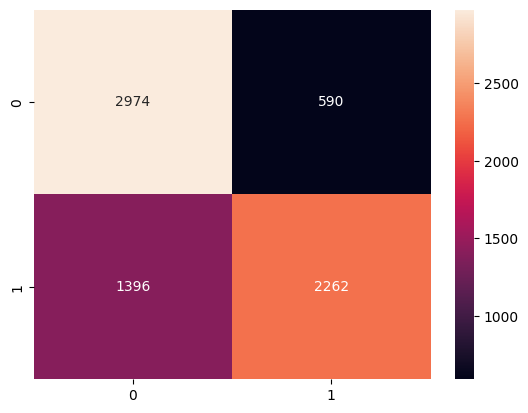

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75      3564
           1       0.79      0.62      0.69      3658

    accuracy                           0.73      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.73      0.72      7222



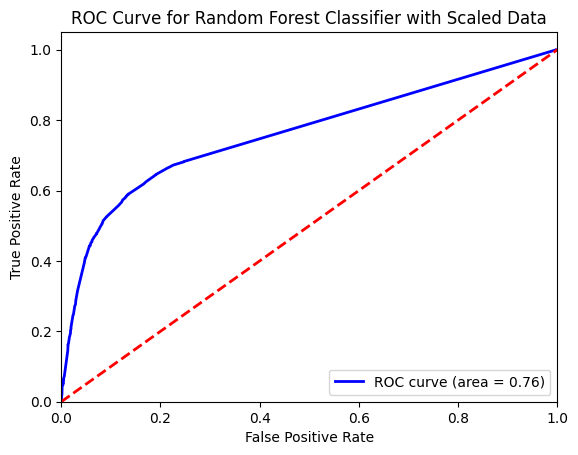

In [5]:
model = RandomForestClassifier(n_estimators=22, criterion='gini', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, model.predict_proba(X_test)[:, 1], title="Random Forest Classifier with Scaled Data")

Accuracy: 0.7245915258931044
Confusion Matrix:


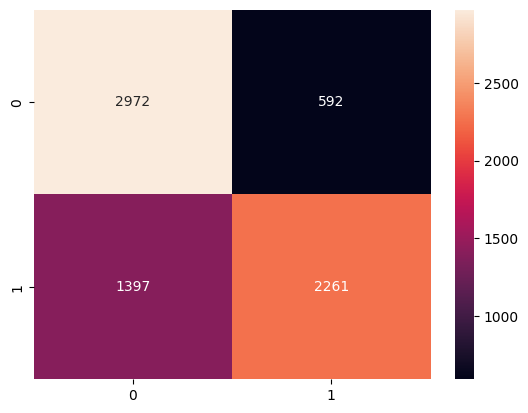

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75      3564
           1       0.79      0.62      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



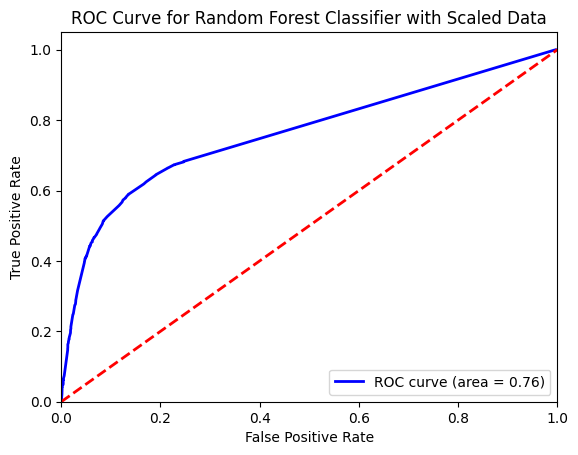

In [6]:
model = RandomForestClassifier(n_estimators=22, criterion='entropy', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, model.predict_proba(X_test)[:, 1], title="Random Forest Classifier with Scaled Data")

### From Scratch

In [47]:
model_scratch = RandomForestClassifierFromScratch(n_trees=30, criterion="gini")
model_scratch.fit(X_train, y_train)
y_pred = model_scratch.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7794368600682594


Accuracy: 0.6643589033508723
Confusion Matrix:


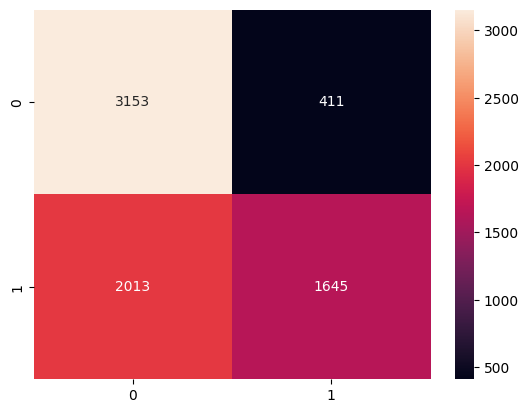

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72      3564
           1       0.80      0.45      0.58      3658

    accuracy                           0.66      7222
   macro avg       0.71      0.67      0.65      7222
weighted avg       0.71      0.66      0.65      7222



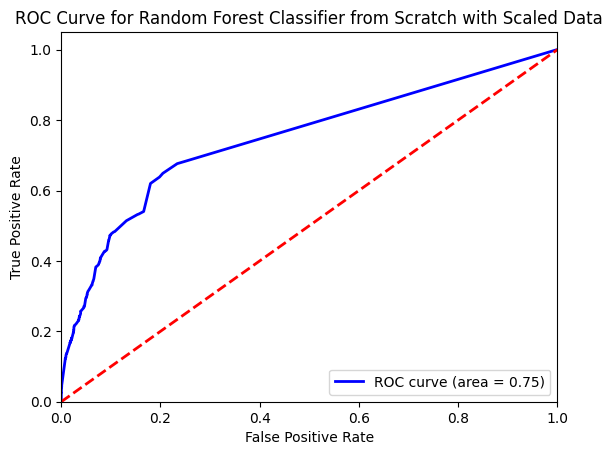

In [7]:
model_scratch = RandomForestClassifierFromScratch(n_trees=22, criterion="gini")
model_scratch.fit(X_train, y_train)
y_pred = model_scratch.predict(X_test)
y_pred_proba = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Random Forest Classifier from Scratch with Scaled Data")

Accuracy: 0.6802824702298532
Confusion Matrix:


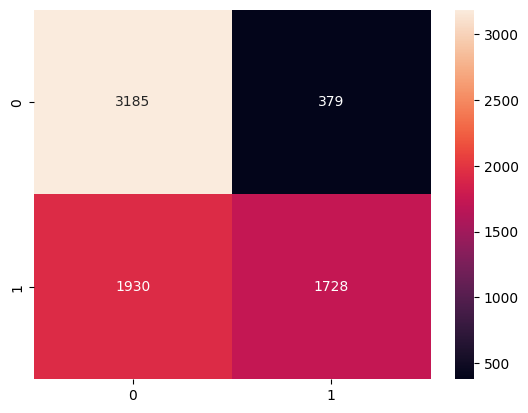

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.89      0.73      3564
           1       0.82      0.47      0.60      3658

    accuracy                           0.68      7222
   macro avg       0.72      0.68      0.67      7222
weighted avg       0.72      0.68      0.67      7222



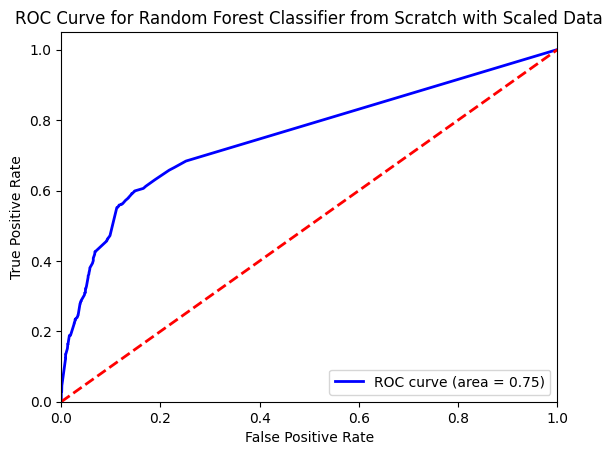

In [10]:
model_scratch = RandomForestClassifierFromScratch(n_trees=22, criterion="entropy")
model_scratch.fit(X_train, y_train)
y_pred = model_scratch.predict(X_test)
y_pred_proba = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Random Forest Classifier from Scratch with Scaled Data")

## All features

In [11]:
X = df.drop('default.payment.next.month', axis=1).values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X, y = SMOTE(random_state=42).fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scikit Learn

Accuracy: 0.8393796732207145
Confusion Matrix:


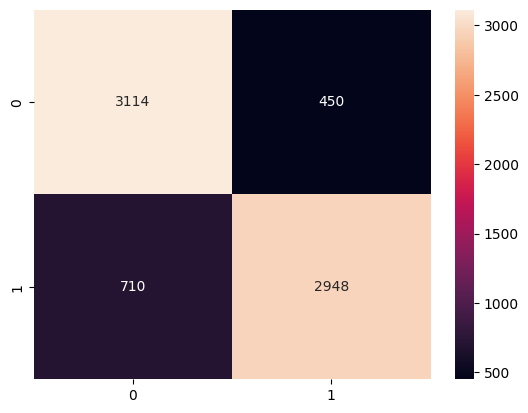

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      3564
           1       0.87      0.81      0.84      3658

    accuracy                           0.84      7222
   macro avg       0.84      0.84      0.84      7222
weighted avg       0.84      0.84      0.84      7222



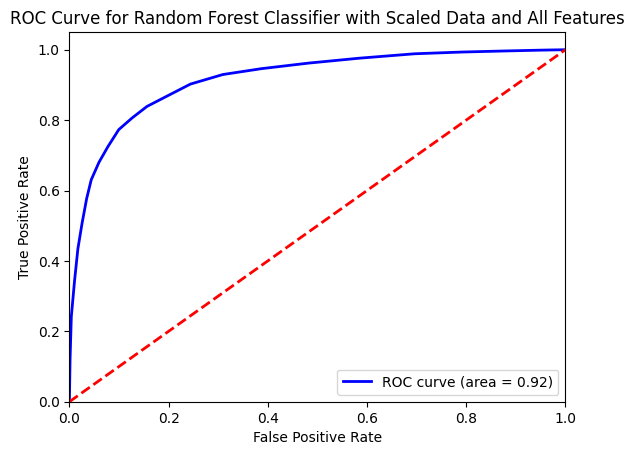

In [13]:
model_scikit = RandomForestClassifier(n_estimators=22, criterion='gini', random_state=42)
model_scikit.fit(X_train, y_train)
y_pred = model_scikit.predict(X_test)
y_pred_proba = model_scikit.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Random Forest Classifier with Scaled Data and All Features")

Accuracy: 0.842841318194406
Confusion Matrix:


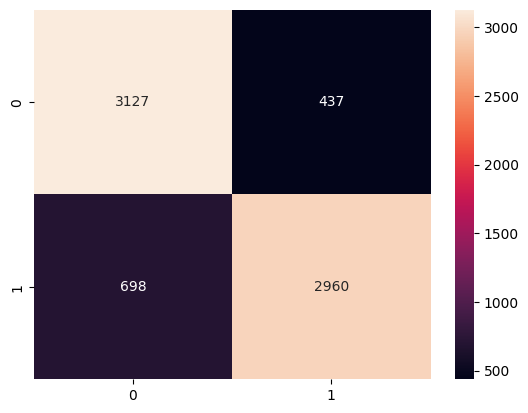

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      3564
           1       0.87      0.81      0.84      3658

    accuracy                           0.84      7222
   macro avg       0.84      0.84      0.84      7222
weighted avg       0.84      0.84      0.84      7222



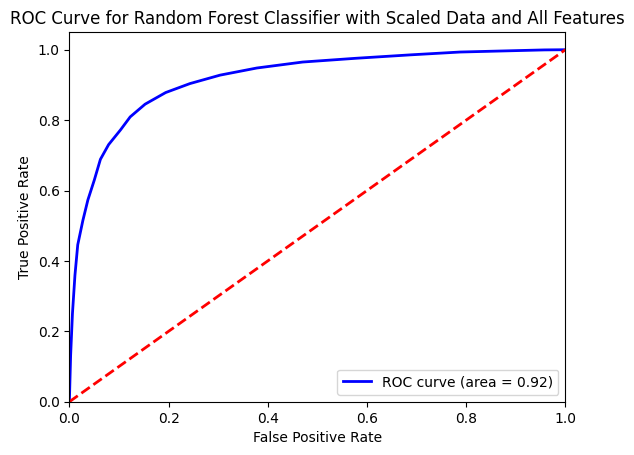

In [12]:
model_scikit = RandomForestClassifier(n_estimators=22, criterion='entropy', random_state=42)
model_scikit.fit(X_train, y_train)
y_pred = model_scikit.predict(X_test)
y_pred_proba = model_scikit.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Random Forest Classifier with Scaled Data and All Features")

### From Scrath

Accuracy: 0.760177236222653
Confusion Matrix:


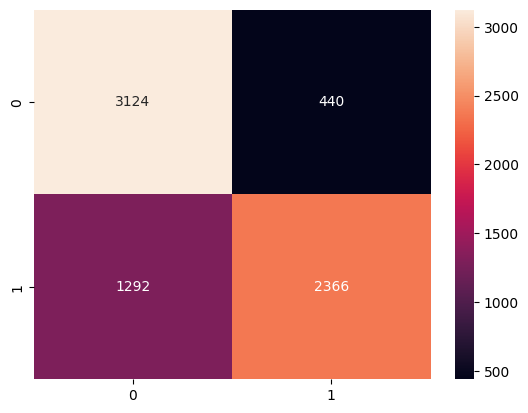

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.88      0.78      3564
           1       0.84      0.65      0.73      3658

    accuracy                           0.76      7222
   macro avg       0.78      0.76      0.76      7222
weighted avg       0.78      0.76      0.76      7222



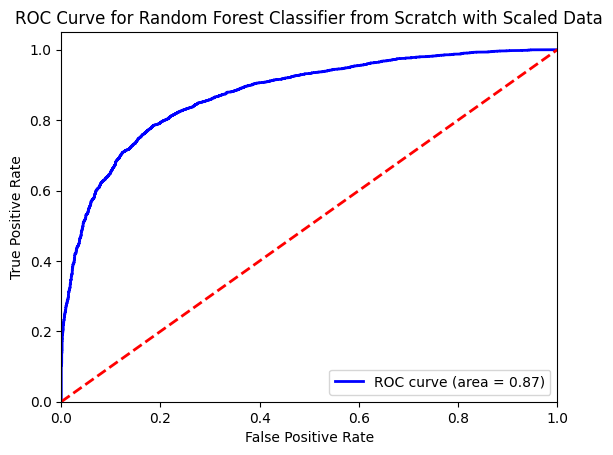

In [16]:
model_scratch = RandomForestClassifierFromScratch(n_trees=22, criterion="gini")
model_scratch.fit(X_train, y_train)
y_pred = model_scratch.predict(X_test)
y_pred_proba = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Random Forest Classifier from Scratch with Scaled Data")

Accuracy: 0.7648850733868734
Confusion Matrix:


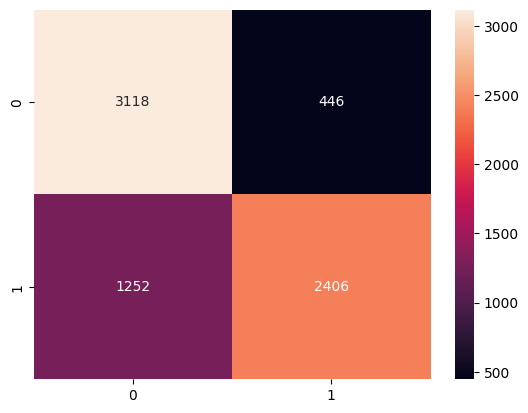

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.87      0.79      3564
           1       0.84      0.66      0.74      3658

    accuracy                           0.76      7222
   macro avg       0.78      0.77      0.76      7222
weighted avg       0.78      0.76      0.76      7222



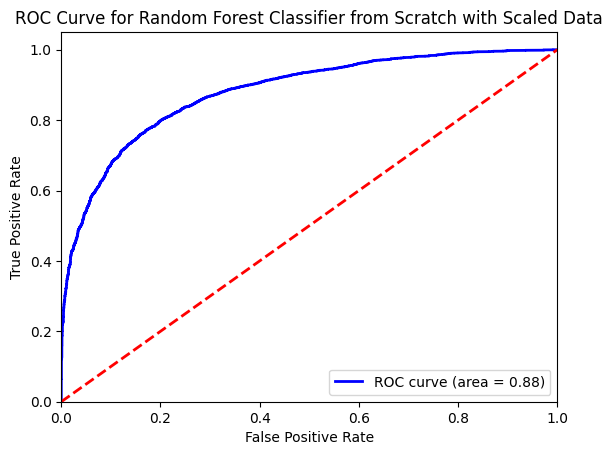

In [17]:
model_scratch = RandomForestClassifierFromScratch(n_trees=22, criterion="entropy")
model_scratch.fit(X_train, y_train)
y_pred = model_scratch.predict(X_test)
y_pred_proba = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Random Forest Classifier from Scratch with Scaled Data")